# Repeated Validation and Confidence Analysis

This notebook evaluates the selected tuned SVM model more carefully than a single test split can. It repeats cross-validation several times to measure stability, then inspects prediction confidence to show how certain the model is for each class.

The goal is to provide stronger evidence that the final classifier is not only accurate, but also reliable across different validation runs.


In [34]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    RandomizedSearchCV,
    cross_val_score
    )
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [35]:
df = pd.read_csv(r'C:\Users\LOQ\Documents\Papers\Iris\data\iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [36]:
target_col = 'species'
X = df.drop(columns=[target_col])
y = df[target_col]

In [37]:
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: species, dtype: object

In [38]:
y.value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [39]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [41]:
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')

Train size: 120 | Test size: 30


In [42]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])

param_space = {
    'model__C': np.logspace(-2, 2, 15),
    'model__gamma': np.logspace(-3, 1, 15)
}

search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_space,
    n_iter=20,
    scoring='accuracy',
    cv=5,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)

best_svm = search.best_estimator_
best_params = search.best_params_
best_cv_mean = search.best_score_

test_pred = best_svm.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print('Tuned SVM ready.')
print(f'Best params: {best_params}')
print(f'CV mean (5-fold): {best_cv_mean:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Tuned SVM ready.
Best params: {'model__gamma': np.float64(0.013894954943731374), 'model__C': np.float64(26.826957952797247)}
CV mean (5-fold): 0.9750
Test accuracy: 1.0000


In [43]:
repeated_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
repeated_scores = cross_val_score(
    best_svm,
    X_train,
    y_train,
    cv=repeated_cv,
    scoring='accuracy',
    n_jobs=-1
    )

mean_acc = repeated_scores.mean()
std_acc = repeated_scores.std(ddof=1)
n_scores = repeated_scores.size
ci95 = 1.96 * std_acc / np.sqrt(n_scores)

print('Repeated CV results (5 folds x 10 repeats):')
print(f'Mean accuracy: {mean_acc:.4f}')
print(f'Std accuracy:  {std_acc:.4f}')
print(f'95% CI:        [{mean_acc - ci95:.4f}, {mean_acc + ci95:.4f}]')


Repeated CV results (5 folds x 10 repeats):
Mean accuracy: 0.9717
Std accuracy:  0.0320
95% CI:        [0.9628, 0.9805]


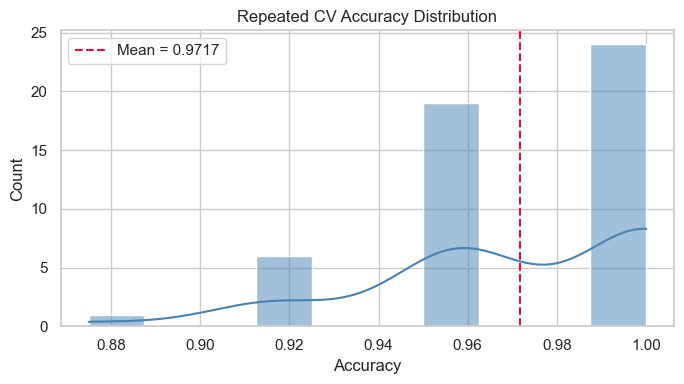

In [44]:
plt.figure(figsize=(7, 4))
sns.histplot(repeated_scores, bins=10, kde=True, color='steelblue')
plt.axvline(mean_acc, color='crimson', linestyle='--', label=f'Mean = {mean_acc:.4f}')
plt.title('Repeated CV Accuracy Distribution')
plt.xlabel('Accuracy')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## Repeated Cross-Validation Results

The histogram in the next cell shows how the accuracy changes across repeated stratified folds. A tight distribution means the model is behaving consistently, while a wide spread would suggest higher sensitivity to the data split.

This step is the main stability check for the final model.


In [45]:
proba = best_svm.predict_proba(X_test)
pred_idx = np.argmax(proba, axis=1)
pred_labels = label_encoder.inverse_transform(pred_idx)
true_labels = label_encoder.inverse_transform(y_test)
max_conf = proba.max(axis=1)

confidence_df = pd.DataFrame({
    'True Label': true_labels,
    'Predicted Label': pred_labels,
    'Confidence': max_conf
})
confidence_df['Correct'] = confidence_df['True Label'] == confidence_df['Predicted Label']

print('Top 10 lowest-confidence predictions:')
confidence_df.sort_values('Confidence').head(10)

Top 10 lowest-confidence predictions:


,True Label,Predicted Label,Confidence,Correct
25,Iris-versicolor,Iris-versicolor,0.560226,True
19,Iris-virginica,Iris-virginica,0.577832,True
1,Iris-virginica,Iris-virginica,0.622682,True
23,Iris-virginica,Iris-virginica,0.627106,True
2,Iris-versicolor,Iris-versicolor,0.847758,True
28,Iris-virginica,Iris-virginica,0.856220,True
9,Iris-versicolor,Iris-versicolor,0.860030,True
3,Iris-versicolor,Iris-versicolor,0.882423,True
5,Iris-versicolor,Iris-versicolor,0.883439,True
8,Iris-virginica,Iris-virginica,0.910883,True


In [46]:
print('Confidence summary by predicted class:')
display(
    confidence_df.groupby('Predicted Label')['Confidence']
    .agg(['count', 'mean', 'min', 'max'])
    .reset_index()
    )


Confidence summary by predicted class:


,Predicted Label,count,mean,min,max
0,Iris-setosa,10,0.971541,0.950500,0.989572
1,Iris-versicolor,10,0.881093,0.560226,0.971847
2,Iris-virginica,10,0.850426,0.577832,0.991462


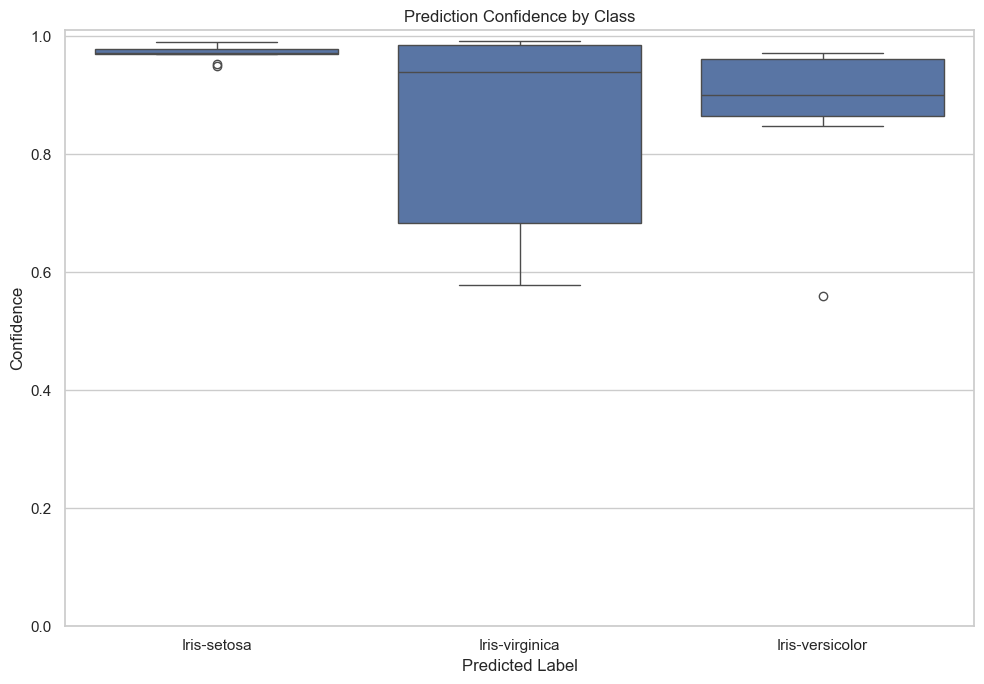

In [54]:
plt.figure(figsize=(10, 7))
sns.boxplot(data=confidence_df, x='Predicted Label', y='Confidence')
plt.ylim(0, 1.01)
plt.title('Prediction Confidence by Class')
plt.tight_layout()
plt.show()

## Confidence Interpretation

The confidence plots explain how strongly the model supports each prediction. Higher confidence on Iris-setosa usually indicates that class is easier to separate, while lower confidence on the other classes reflects their closer overlap in feature space.

Together with the confusion matrix, this gives a more complete picture than accuracy alone.


In [48]:
cm = confusion_matrix(y_test, test_pred)
report_dict = classification_report(
    y_test,
    test_pred,
    target_names=label_encoder.classes_,
    output_dict=True
    )

In [49]:


log_row = {
    'timestamp': datetime.now().isoformat(timespec='seconds'),
    'model': 'SVM (RBF) - tuned',
    'best_params': str(best_params),
    'cv_mean_5fold': float(best_cv_mean),
    'repeated_cv_mean': float(mean_acc),
    'repeated_cv_std': float(std_acc),
    'repeated_cv_ci95_low': float(mean_acc - ci95),
    'repeated_cv_ci95_high': float(mean_acc + ci95),
    'test_accuracy': float(test_acc),
    'macro_f1': float(report_dict['macro avg']['f1-score']),
    'weighted_f1': float(report_dict['weighted avg']['f1-score'])
}

log_path = Path(r'C:\Users\LOQ\Documents\Papers\Iris\artifacts\experiment_log.csv')

if log_path.exists():
    existing = pd.read_csv(log_path)
    updated = pd.concat([existing, pd.DataFrame([log_row])], ignore_index=True)
else:
    updated = pd.DataFrame([log_row])

updated.to_csv(log_path, index=False)
print(f'Experiment logged to: {log_path.resolve()}')
updated.tail(5)



Experiment logged to: C:\Users\LOQ\Documents\Papers\Iris\artifacts\experiment_log.csv


,timestamp,model,best_params,cv_mean_5fold,repeated_cv_mean,repeated_cv_std,repeated_cv_ci95_low,repeated_cv_ci95_high,test_accuracy,macro_f1,weighted_f1
0,2026-04-19T09:59:25,SVM (RBF) - tuned,{'model__gamma': np.float64(0.0138949549437313...,0.975,0.971667,0.031988,0.9628,0.980533,1.0,1.0,1.0
1,2026-04-19T17:35:41,SVM (RBF) - tuned,{'model__gamma': np.float64(0.0138949549437313...,0.975,0.971667,0.031988,0.9628,0.980533,1.0,1.0,1.0
2,2026-04-19T17:36:38,SVM (RBF) - tuned,{'model__gamma': np.float64(0.0138949549437313...,0.975,0.971667,0.031988,0.9628,0.980533,1.0,1.0,1.0
3,2026-04-20T16:09:49,SVM (RBF) - tuned,{'model__gamma': np.float64(0.0138949549437313...,0.975,0.971667,0.031988,0.9628,0.980533,1.0,1.0,1.0


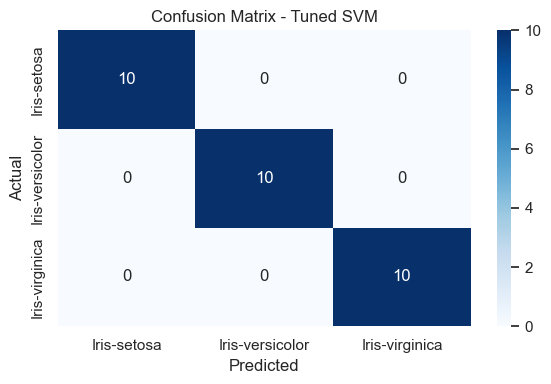

In [50]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
    )
plt.title('Confusion Matrix - Tuned SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [51]:
conclusion_lines = [
    'Final Conclusion',
    f"- Tuned model: SVM (RBF) with params: {best_params}",
    f"- Single split test accuracy: {test_acc:.4f}",
    f"- Repeated CV mean +/- std: {mean_acc:.4f} +/- {std_acc:.4f}",
    f"- 95% CI from repeated CV: [{mean_acc - ci95:.4f}, {mean_acc + ci95:.4f}]",
    '- Confidence analysis shows prediction certainty distribution by class.',
    '- Recommendation: use this tuned SVM as final baseline and report both test and repeated CV metrics.'
]

print('\n'.join(conclusion_lines))

conclusion_df = pd.DataFrame({
    'Metric': [
        'Model',
        'Best Parameters',
        'Test Accuracy',
        'Repeated CV Mean',
        'Repeated CV Std',
        'Repeated CV 95% CI',
        'Macro F1',
        'Weighted F1'
    ],
    'Value': [
        'SVM (RBF) - tuned',
        str(best_params),
        f'{test_acc:.4f}',
        f'{mean_acc:.4f}',
        f'{std_acc:.4f}',
        f'[{mean_acc - ci95:.4f}, {mean_acc + ci95:.4f}]',
        f"{report_dict['macro avg']['f1-score']:.4f}",
        f"{report_dict['weighted avg']['f1-score']:.4f}"
    ]
})
conclusion_df

Final Conclusion
- Tuned model: SVM (RBF) with params: {'model__gamma': np.float64(0.013894954943731374), 'model__C': np.float64(26.826957952797247)}
- Single split test accuracy: 1.0000
- Repeated CV mean +/- std: 0.9717 +/- 0.0320
- 95% CI from repeated CV: [0.9628, 0.9805]
- Confidence analysis shows prediction certainty distribution by class.
- Recommendation: use this tuned SVM as final baseline and report both test and repeated CV metrics.


,Metric,Value
0,Model,SVM (RBF) - tuned
1,Best Parameters,{'model__gamma': np.float64(0.0138949549437313...
2,Test Accuracy,1.0000
3,Repeated CV Mean,0.9717
4,Repeated CV Std,0.0320
5,Repeated CV 95% CI,"[0.9628, 0.9805]"
6,Macro F1,1.0000
7,Weighted F1,1.0000


## Report-Ready Summary

Use this output as a concise results paragraph for your report or paper.


In [52]:
print(f"The tuned SVM (RBF) model achieved a single-split test accuracy of {test_acc:.4f}. ")
print(f"To assess stability, repeated stratified 5-fold cross-validation with 10 repeats produced a mean accuracy of {mean_acc:.4f} ")
print(f"with standard deviation {std_acc:.4f} and a 95% confidence interval of [{mean_acc - ci95:.4f}, {mean_acc + ci95:.4f}]. ")
print(f"The tuned configuration {best_params} was selected as the final model because it combined strong predictive performance with stable repeated-CV results. ")
print(f"The classification report showed macro F1-score of {report_dict['macro avg']['f1-score']:.4f} and weighted F1-score of {report_dict['weighted avg']['f1-score']:.4f}, ")
print("indicating consistent performance across all Iris classes.")


The tuned SVM (RBF) model achieved a single-split test accuracy of 1.0000. 
To assess stability, repeated stratified 5-fold cross-validation with 10 repeats produced a mean accuracy of 0.9717 
with standard deviation 0.0320 and a 95% confidence interval of [0.9628, 0.9805]. 
The tuned configuration {'model__gamma': np.float64(0.013894954943731374), 'model__C': np.float64(26.826957952797247)} was selected as the final model because it combined strong predictive performance with stable repeated-CV results. 
The classification report showed macro F1-score of 1.0000 and weighted F1-score of 1.0000, 
indicating consistent performance across all Iris classes.


In [53]:
report_summary = pd.DataFrame({
    'Metric': [
        'Model',
        'Best Params',
        'Test Accuracy',
        'Repeated CV Mean',
        'Repeated CV Std',
        'Repeated CV 95% CI',
        'Macro F1',
        'Weighted F1'
    ],
    'Value': [
        'SVM (RBF) - tuned',
        str(best_params),
        f'{test_acc:.4f}',
        f'{mean_acc:.4f}',
        f'{std_acc:.4f}',
        f'[{mean_acc - ci95:.4f}, {mean_acc + ci95:.4f}]',
        f"{report_dict['macro avg']['f1-score']:.4f}",
        f"{report_dict['weighted avg']['f1-score']:.4f}"
    ]
})

report_summary

,Metric,Value
0,Model,SVM (RBF) - tuned
1,Best Params,{'model__gamma': np.float64(0.0138949549437313...
2,Test Accuracy,1.0000
3,Repeated CV Mean,0.9717
4,Repeated CV Std,0.0320
5,Repeated CV 95% CI,"[0.9628, 0.9805]"
6,Macro F1,1.0000
7,Weighted F1,1.0000
